In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('/usr/local/faststorage/datasets/isic/ISIC_2019_Training_GroundTruth.csv')

In [3]:
df.head()

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#remove the first column
df = df.iloc[:, 1:]

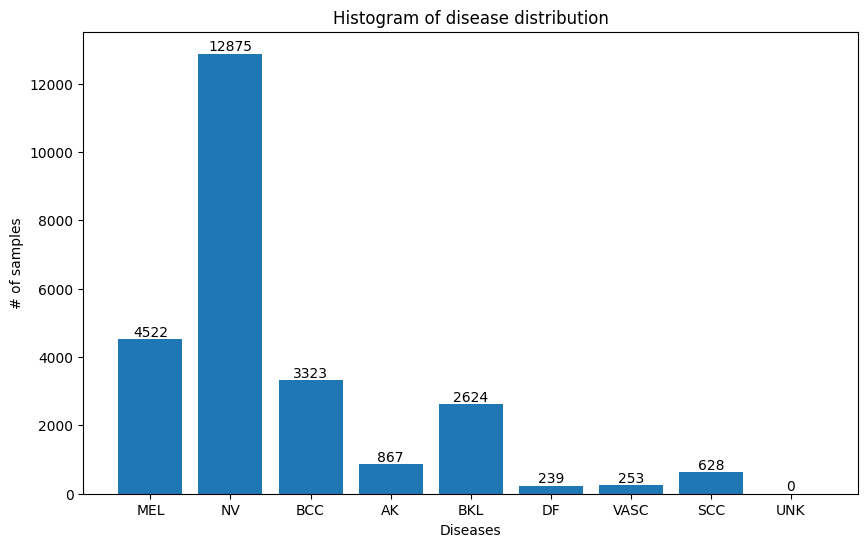

In [5]:
ones_count = (df == 1).sum()
plt.figure(figsize=(10, 6))
bars = plt.bar(ones_count.index, ones_count.values)
plt.title('Histogram of disease distribution')
plt.xlabel('Diseases')
plt.ylabel('# of samples')

# Add text labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')
    
plt.show()

# Create split

In [12]:
df = pd.read_csv('/usr/local/faststorage/datasets/isic/ISIC_2019_Training_GroundTruth.csv')
#remove the last column
df = df.iloc[:, :-1]

train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df.iloc[:, 1:].idxmax(axis=1)  # Stratify based on the class labels
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15/0.85,  # Adjust validation size to get 15% of original data
    random_state=42,
    stratify=train_val_df.iloc[:, 1:].idxmax(axis=1)
)

# Print split sizes
print(f"Total samples: {len(df)}")
print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

# Print class distribution for each split
def print_class_distribution(data, split_name):
    class_dist = data.iloc[:, 1:].sum()
    print(f"\n{split_name} set class distribution:")
    for class_name, count in class_dist.items():
        print(f"{class_name}: {count}")

print_class_distribution(train_df, "Training")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test")

# Save splits to CSV files
train_df.to_csv('../data/isic/isic_train.csv', index=False)
val_df.to_csv('../data/isic/isic_val.csv', index=False)
test_df.to_csv('../data/isic/isic_test.csv', index=False)

Total samples: 25331
Training set: 17731 samples
Validation set: 3800 samples
Test set: 3800 samples

Training set class distribution:
MEL: 3166.0
NV: 9012.0
BCC: 2326.0
AK: 607.0
BKL: 1836.0
DF: 167.0
VASC: 177.0
SCC: 440.0

Validation set class distribution:
MEL: 678.0
NV: 1932.0
BCC: 498.0
AK: 130.0
BKL: 394.0
DF: 36.0
VASC: 38.0
SCC: 94.0

Test set class distribution:
MEL: 678.0
NV: 1931.0
BCC: 499.0
AK: 130.0
BKL: 394.0
DF: 36.0
VASC: 38.0
SCC: 94.0


<Figure size 2000x600 with 0 Axes>

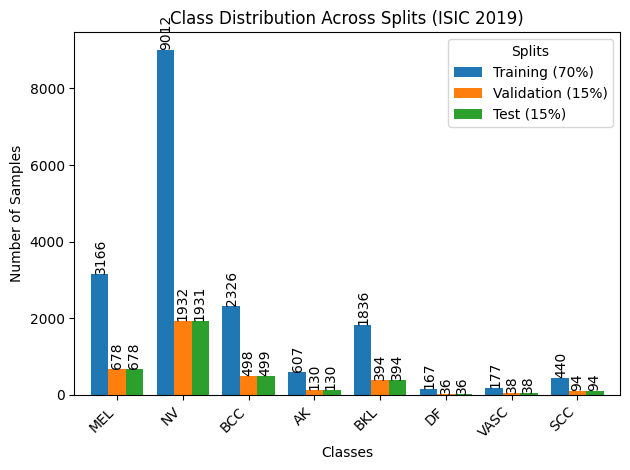


Percentage Distribution:
Training: 70.0%
Validation: 15.0%
Test: 15.0%


In [16]:
# Calculate class distributions
train_dist = train_df.iloc[:, 1:].sum()
val_dist = val_df.iloc[:, 1:].sum()
test_dist = test_df.iloc[:, 1:].sum()

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Training (70%)': train_dist,
    'Validation (15%)': val_dist,
    'Test (15%)': test_dist
})

# Create the plot
plt.figure(figsize=(20, 6))
plot_data.plot(kind='bar', width=0.8)
plt.title('Class Distribution Across Splits (ISIC 2019)')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Splits')

# Add value labels on top of bars
for i in range(len(plot_data)):
    for j, col in enumerate(plot_data.columns):
        value = plot_data.iloc[i, j]
        plt.text(i + (j-1)*0.25, value, f'{int(value)}', 
                ha='center', va='bottom', rotation=90)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Print percentage distribution
print("\nPercentage Distribution:")
total_samples = len(train_df) + len(val_df) + len(test_df)
print(f"Training: {len(train_df)/total_samples*100:.1f}%")
print(f"Validation: {len(val_df)/total_samples*100:.1f}%")
print(f"Test: {len(test_df)/total_samples*100:.1f}%")



# Analyze annotations

In [13]:
# analyze json file
import json
import pandas as pd

#read a json file
with open('/home/amarkr/dent/data/isic/skin_lesion_anotations_4k_2023.json') as f:
    data = json.load(f)

In [15]:
import json
from collections import Counter
from typing import List, Dict
import pandas as pd

def analyze_skin_lesion_data(data: List[Dict]) -> Dict:
    """
    Analyze skin lesion image metadata.
    
    Args:
        data: List of dictionaries containing image metadata
        
    Returns:
        Dictionary containing analysis results
    """
    # Initialize analysis results
    analysis = {
        'total_images': len(data),
        'type_distribution': Counter(),
        'hair_presence': Counter(),
        'hair_types': Counter(),
        'frame_presence': Counter(),
        'ruler_mark_presence': Counter(),
        'other_artifacts': Counter()
    }
    
    # Analyze each entry
    for entry in data:
        # Count lesion types
        analysis['type_distribution'][entry['type']] += 1
        
        # Count hair presence and types
        analysis['hair_presence'][entry['hair']] += 1
        if entry['hair']:
            analysis['hair_types'][entry['hair_type']] += 1
            
        # Count other artifacts
        analysis['frame_presence'][entry['frame']] += 1
        analysis['ruler_mark_presence'][entry['ruler_mark']] += 1
        analysis['other_artifacts'][entry['other']] += 1
    
    return analysis

def print_analysis(analysis: Dict):
    """
    Print formatted analysis results.
    
    Args:
        analysis: Dictionary containing analysis results
    """
    print(f"Total Images Analyzed: {analysis['total_images']}")
    print("\nLesion Type Distribution:")
    for type_name, count in analysis['type_distribution'].items():
        percentage = (count / analysis['total_images']) * 100
        print(f"- {type_name}: {count} ({percentage:.1f}%)")
    
    print("\nImage Quality Metrics:")
    print(f"Hair Present: {analysis['hair_presence'][True]} images")
    print("\nHair Type Distribution:")
    total_with_hair = analysis['hair_presence'][True]
    if total_with_hair > 0:
        for hair_type, count in analysis['hair_types'].items():
            percentage = (count / total_with_hair) * 100
            print(f"- {hair_type}: {count} ({percentage:.1f}%)")
    
    print("\nArtifact Presence:")
    print(f"- Frames: {analysis['frame_presence'][True]} images")
    print(f"- Ruler Marks: {analysis['ruler_mark_presence'][True]} images")
    print(f"- Other Artifacts: {analysis['other_artifacts'][True]} images")

def create_dataframe(data: List[Dict]) -> pd.DataFrame:
    """
    Convert the JSON data to a pandas DataFrame for additional analysis.
    
    Args:
        data: List of dictionaries containing image metadata
        
    Returns:
        pandas DataFrame
    """
    return pd.DataFrame(data)

# Example usage
if __name__ == "__main__":
    with open('/home/amarkr/dent/data/isic/skin_lesion_anotations_4k_2023.json') as f:
        data = json.load(f)
    
    # Perform analysis
    results = analyze_skin_lesion_data(data)
    print_analysis(results)
    
    # Create DataFrame for additional analysis
    df = create_dataframe(data)
    
    # Additional DataFrame analysis examples
    print("\nDataFrame Analysis:")
    print(f"Total unique lesion types: {df['type'].nunique()}")
    print("\nCorrelation between features:")
    print(df[['hair', 'frame', 'ruler_mark', 'other']].corr())

Total Images Analyzed: 4001

Lesion Type Distribution:
- malignant: 2000 (50.0%)
- benign: 2001 (50.0%)

Image Quality Metrics:
Hair Present: 1826 images

Hair Type Distribution:
- normal: 1324 (72.5%)
- dense: 303 (16.6%)
- short: 199 (10.9%)

Artifact Presence:
- Frames: 625 images
- Ruler Marks: 1008 images
- Other Artifacts: 1244 images

DataFrame Analysis:
Total unique lesion types: 2

Correlation between features:
                hair     frame  ruler_mark     other
hair        1.000000 -0.044561   -0.087888 -0.121139
frame      -0.044561  1.000000    0.086488 -0.042130
ruler_mark -0.087888  0.086488    1.000000  0.009441
other      -0.121139 -0.042130    0.009441  1.000000


## visualize annotation

In [16]:
df = pd.read_csv('/home/jupyter/isic/melanoma/train_concat.csv')

In [17]:
df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,0


In [18]:
# check if all the images in image_name column are present in the directory
import os

# Path to the image directory
image_dir = '/home/jupyter/isic/melanoma/train'

# Check if all images in the DataFrame are present in the directory
missing_images = []
for image_name in df['image_name']:
    image_path = os.path.join(image_dir, image_name)
    if not os.path.exists(image_path):
        missing_images.append(image_name)


In [20]:
len(missing_images)

37648

In [21]:
len(df['image_name'])

37648

In [25]:
#check the common name between the json file and the csv file
# Extract the image names from the JSON file
json_image_names = [entry['filename'] for entry in data]

# Extract the image names from the CSV file
csv_image_names = df['image_name'].values

# Find the common image names
common_image_names = set(json_image_names).intersection(csv_image_names)

# Check the number of common image names
len(common_image_names)



0

In [49]:
json_image_names = {entry['filename'] for entry in data}
        
# Read CSV file and extract image names
df = pd.read_csv('/home/jupyter/isic/ISIC_2019_Training_GroundTruth.csv')
csv_image_names = set(df['image'].values)
#add .jpg to the image names
csv_image_names = {f"{name}.jpg" for name in csv_image_names}

# Find common images
common_images = json_image_names.intersection(csv_image_names)

# Print summary
print(f"Total images in JSON: {len(json_image_names)}")
print(f"Total images in CSV: {len(csv_image_names)}")
print(f"Number of common images: {len(common_images)}")
print(f"Percentage of JSON images in CSV: {(len(common_images)/len(json_image_names))*100:.2f}%")
print(f"Percentage of CSV images in JSON: {(len(common_images)/len(csv_image_names))*100:.2f}%")
        

Total images in JSON: 4000
Total images in CSV: 25331
Number of common images: 2515
Percentage of JSON images in CSV: 62.88%
Percentage of CSV images in JSON: 9.93%


In [35]:
csv_image_names

{'ISIC_0028172',
 'ISIC_0065259',
 'ISIC_0064863',
 'ISIC_0033442',
 'ISIC_0073012',
 'ISIC_0028859',
 'ISIC_0068249',
 'ISIC_0073219',
 'ISIC_0059104',
 'ISIC_0072896',
 'ISIC_0030529',
 'ISIC_0067948',
 'ISIC_0071352',
 'ISIC_0031299',
 'ISIC_0000255',
 'ISIC_0055731',
 'ISIC_0060470',
 'ISIC_0064553',
 'ISIC_0014513_downsampled',
 'ISIC_0013490_downsampled',
 'ISIC_0028694',
 'ISIC_0026014',
 'ISIC_0060602',
 'ISIC_0033251',
 'ISIC_0058069',
 'ISIC_0024396',
 'ISIC_0027740',
 'ISIC_0059863',
 'ISIC_0025539',
 'ISIC_0029016',
 'ISIC_0060143',
 'ISIC_0063986',
 'ISIC_0027283',
 'ISIC_0055858',
 'ISIC_0026513',
 'ISIC_0056529',
 'ISIC_0057518',
 'ISIC_0072147',
 'ISIC_0063745',
 'ISIC_0055924',
 'ISIC_0056237',
 'ISIC_0066313',
 'ISIC_0027982',
 'ISIC_0026774',
 'ISIC_0029799',
 'ISIC_0026849',
 'ISIC_0013772_downsampled',
 'ISIC_0026740',
 'ISIC_0024564',
 'ISIC_0062584',
 'ISIC_0069754',
 'ISIC_0033773',
 'ISIC_0024665',
 'ISIC_0031700',
 'ISIC_0060585',
 'ISIC_0071378',
 'ISIC_00280

In [32]:
json_image_names

{'ISIC_0059326.jpg',
 'ISIC_0268784.jpg',
 'ISIC_0014527_downsampled.jpg',
 'ISIC_0013833_downsampled.jpg',
 'ISIC_0314462.jpg',
 'ISIC_0009941.jpg',
 'ISIC_0311853.jpg',
 'ISIC_0011294.jpg',
 'ISIC_0028773.jpg',
 'ISIC_0000024_downsampled.jpg',
 'ISIC_0054941.jpg',
 'ISIC_0012756_downsampled.jpg',
 'ISIC_0489729.jpg',
 'ISIC_0055450.jpg',
 'ISIC_0027622.jpg',
 'ISIC_0000306.jpg',
 'ISIC_0056136.jpg',
 'ISIC_0027552.jpg',
 'ISIC_0028033.jpg',
 'ISIC_0025964.jpg',
 'ISIC_0302103.jpg',
 'ISIC_0033980.jpg',
 'ISIC_0014316_downsampled.jpg',
 'ISIC_0013696_downsampled.jpg',
 'ISIC_0010206.jpg',
 'ISIC_5037784.jpg',
 'ISIC_0215054.jpg',
 'ISIC_0025751.jpg',
 'ISIC_0433569.jpg',
 'ISIC_0028352.jpg',
 'ISIC_4009870.jpg',
 'ISIC_0053545.jpg',
 'ISIC_0009948.jpg',
 'ISIC_0203233.jpg',
 'ISIC_0026239.jpg',
 'ISIC_0192490.jpg',
 'ISIC_0056226.jpg',
 'ISIC_0056127.jpg',
 'ISIC_0301931.jpg',
 'ISIC_0154032.jpg',
 'ISIC_0010257.jpg',
 'ISIC_0059277.jpg',
 'ISIC_0105145.jpg',
 'ISIC_0255796.jpg',
 'IS